<br><br><br>
<h2><font size=6>Práctica 2</font></h2>



<h1><font size=7>Sistemas Basados en Reglas Difusas</font></h1>

<br>
<div style="text-align: right">
<font size=4>Pablo Torrijos Arenas (Pablo.Torrijos@uclm.es)</font><br>
<font size=4>José Miguel Puerta Callejón (Jose.Puerta@uclm.es)</font><br>
</div>

**<font color="#B30033" size=5>Estudiantes: </font>** 

* Estudiante 1
* (Estudiante 2)


<br>

<a id="introduccion"></a>
# <font color="#004D7F"> 1. Introducción</font>

En esta práctica vamos a aprender y después utilizar para inferencia un sistema de reglas difusas para clasificación de tipo Mandani basado en variables difusas lingüísticas. Para ello vamos a partir, como siempre, de una base de datos con las variables predictoras y la variable objetivo a predecir. 

Para entender un poco mejor en que consiste un sistema de reglas difusas, vamos a ver dos ejemplos con otras bases de datos. Primero, un caso donde, a partir de la calidad de la comida y del servicio, decidiremos si dar propina o no. En base a esto, podemos aprender un sistema difuso con reglas de la forma:

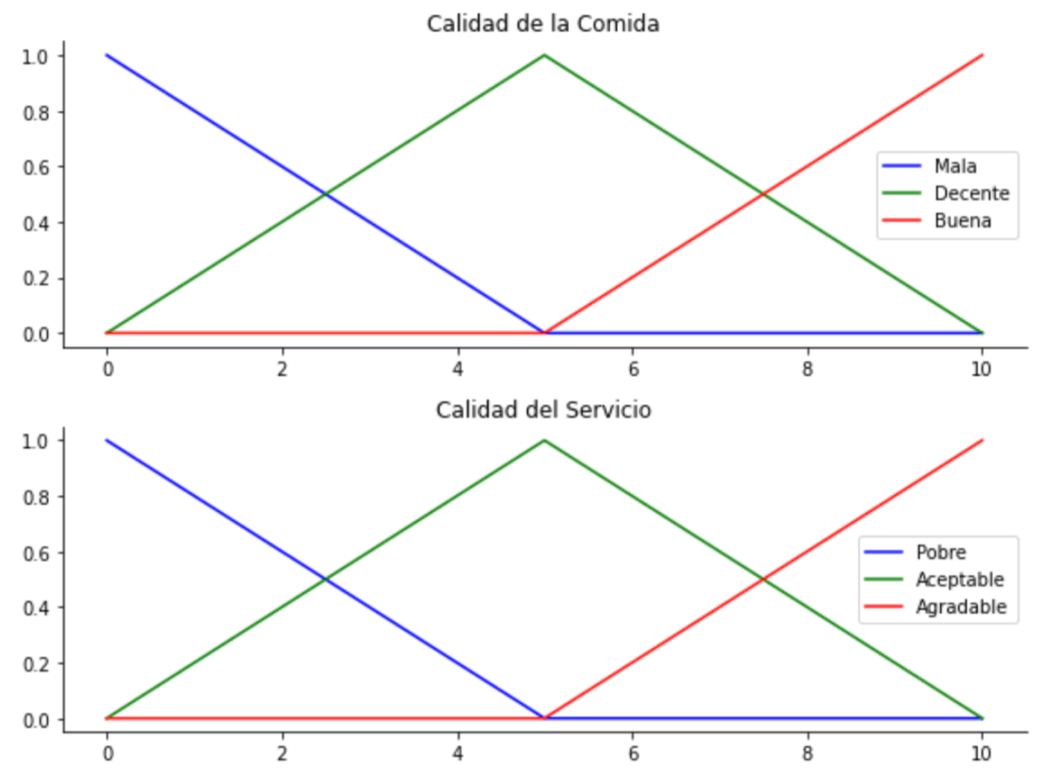

- Si _CC_ es Buena y _CS_ es Agradable entonces Propina es Si 
- Si _CC_ es Mala y _CS_ es Aceptable entonces Propina es No 
- Si _CC_ es Decente y _CS_ es Aceptable entonces Propina es Si 

<br>

### <font color="#004D7F"> 1.2 Inferencia en la clasificación de una instancia</font>

Una vez definido nuestro sistema de reglas difusas lingüísticas para clasificación extraídas del árbol de decisión, tenemos que ver cómo realizar la inferencia para clasificar una nueva instancia.

Esta inferencia se puede realizar directamente en el procesado del árbol, o también utilizando el sistema de reglas extraído. Las dos formas son equivalentes y podrás implementar la que quieras.

#### **Inferencia utilizando el Sistema de Reglas Difusas:**


Otro ejemplo, es el que ya conocemos de la calidad del vino: 

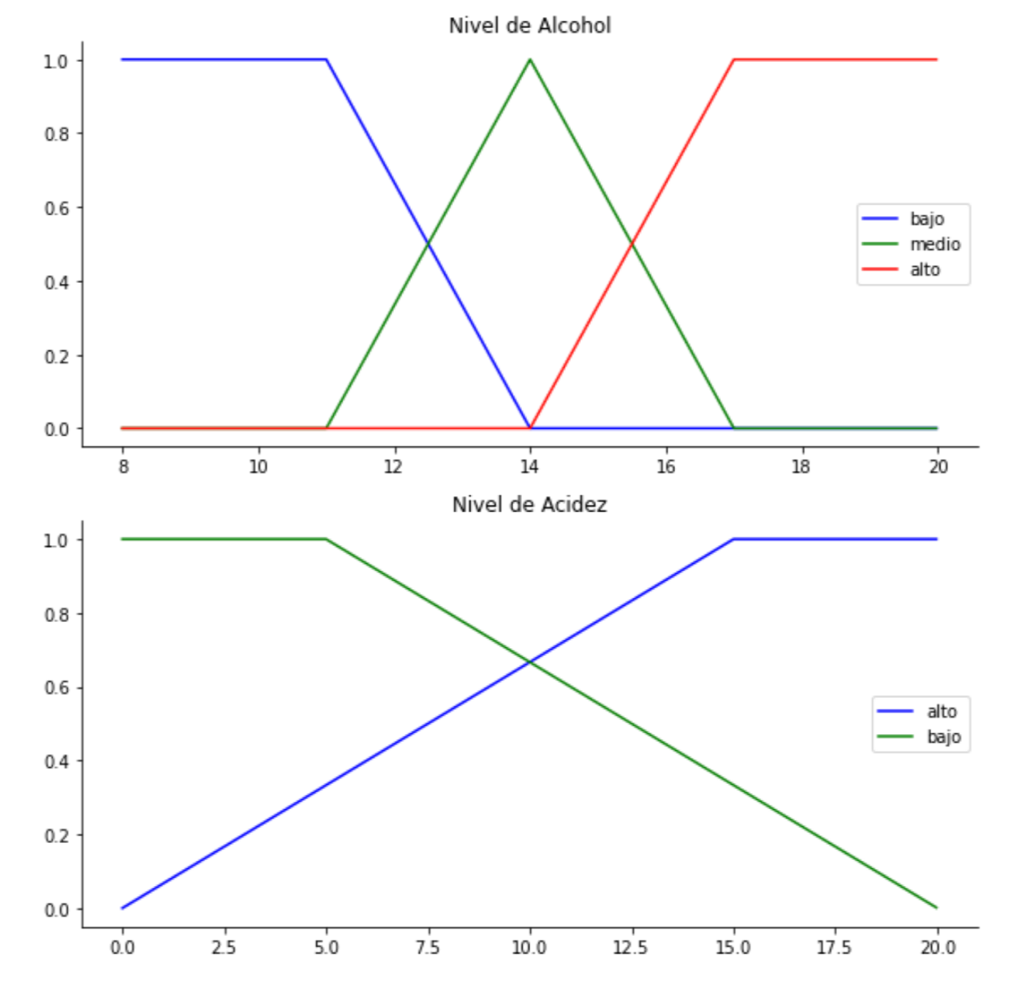

- Si _NAl_ es Bajo y _NAc_ es Alto entonces Calidad es Mala 
- Si _NAl_ es Medio y _NAc_ es Bajo entonces Calidad es Buena 
- Si _NAl_ es Alto y _NAc_ es Bajo entonces Calidad es Buena 

En este caso se disparan todas las reglas con el ejemplo que tengamos, y calculamos el grado de cobertura que tiene cada una de las reglas mediante la T-Norma definida si las reglas son conjunciones. Es decir, si tenemos la T-Norma del mínimo, nos quedamos con el valor mínimo para la relación difusa de la premisa de la regla. En el caso de tener una premisa discreta, no difusa, su función de pertenencia será cero si no corresponden los valores de la premisa con el del ejemplo, o uno si corresponde, es decir es una premisa no difusa, con valores de verdad uno o cero.

La decisión final sobre la salida de la variable clase se realizará de la siguiente forma: cada regla tendrá un grado de cobertura o recubrimiento y un valor de salida para la variable clase, lo notaremos como $r_i:\{C_i,w_i\}$, donde $C_i$ es el valor de la clase y $w_i$ es el grado de cubrimiento de la regla al ejemplo. 

El valor de clase de salida para el ejemplo se calculará cómo la clase mayoritaria ponderada por su valor de recubrimiento o cobertura, es decir, para la clase $C_i$ el número de votos será $∑_{r_j/C_j==C_i}w_j$ , es decir sumamos por cada regla que tenga como salida $C_i$ el valor de su grado de cobertura. Una vez calculado esto para cada etiqueta de salida, nos quedamos con la mayoritaria.

Por ejemplo, imaginad que tenemos el siguiente SBRDL tipo Mandani y la instancia a clasificar: **Nivel de Alcohol = 15, Nivel de Acidez = 5, Tipo = Blanco**. Esperamos ver la Calidad del vino como salida.

- $r_1$: Si NAl es Bajo entonces Calidad es Mala —> $r_1:\{Mala,w_i=0\}; μ_{Bajo}^{NAl} (15)=0$
- $r_5$: Si NAl es Alto entonces Calidad es Buena —> $r_5:\{Buena,w_i=0.33\}; μ_{Alto}^{NAl} (15)=0.33$
- $r_4$: Si NAl es Medio y NAc es Alto entonces Calidad es Mala —> $r_4:\{Mala,w_i=0.33\}; \min(μ_{Medio}^{NAl} (15)=0.66, μ_{Alto}^{NAc} (5)=0.33) = 0.33$
- $r_3$: Si NAl es Medio y NAc es Bajo y Tipo es Tinto entonces Calidad es Mala —> $r_3:\{Mala,w_i=0\}$. Tiene peso 0 porque Tipo es Blanco y en la regla tenemos Tipo es Tinto.
- $r_2$: Si NAl es Medio y NAc es Bajo y Tipo es Blanco entonces Calidad es Buena —> $r_2:\{Buena,w_i=0.66\}; \min(μ_{Medio}^{NAl} (15)=0.66, μ_{Bajo}^{NAc} (5)=0.66,  1) = 0.66$

En este caso tenemos la suma de:
- $Buena = r_2 (0.66) + r_5 (0.33) = 0.99$
- $Mala = r_1(0) +r_4(0.33) +r_3(0) = 0.33$

por lo que se clasificaría como Buena

#### **Inferencia utilizando un árbol de decision difuso:**

En nuestra práctica vamos a utilizar como modelo resultado del aprendizaje a partir de datos un árbol de decisión (difuso). Este árbol de decisión lo vamos a aprender fuzzificando los valores contínuos de las variables de nuestro dataset y dejando como discretas aquellas variables que lo sean de inicio en nuestro dataset. Fuzzificar va a consisistir en cambiar los valores contínuos por su etiqueta difusa correspondiente.

Una vez que tenegamos esta base de datos "fuzzificada" tendremos, de hecho, una base de datos con todas las variables discretas, esto es, todos los valores que aparecen en los datos son etiquetas. Por tanto podemos utilizar un algoritmo de aprendizaje de árboles de decisión para tener como resultado un árbol de decisión, esta vez difuso, ya que los valores de las ramas de los atributos contínuos serán etiquetas difusas.

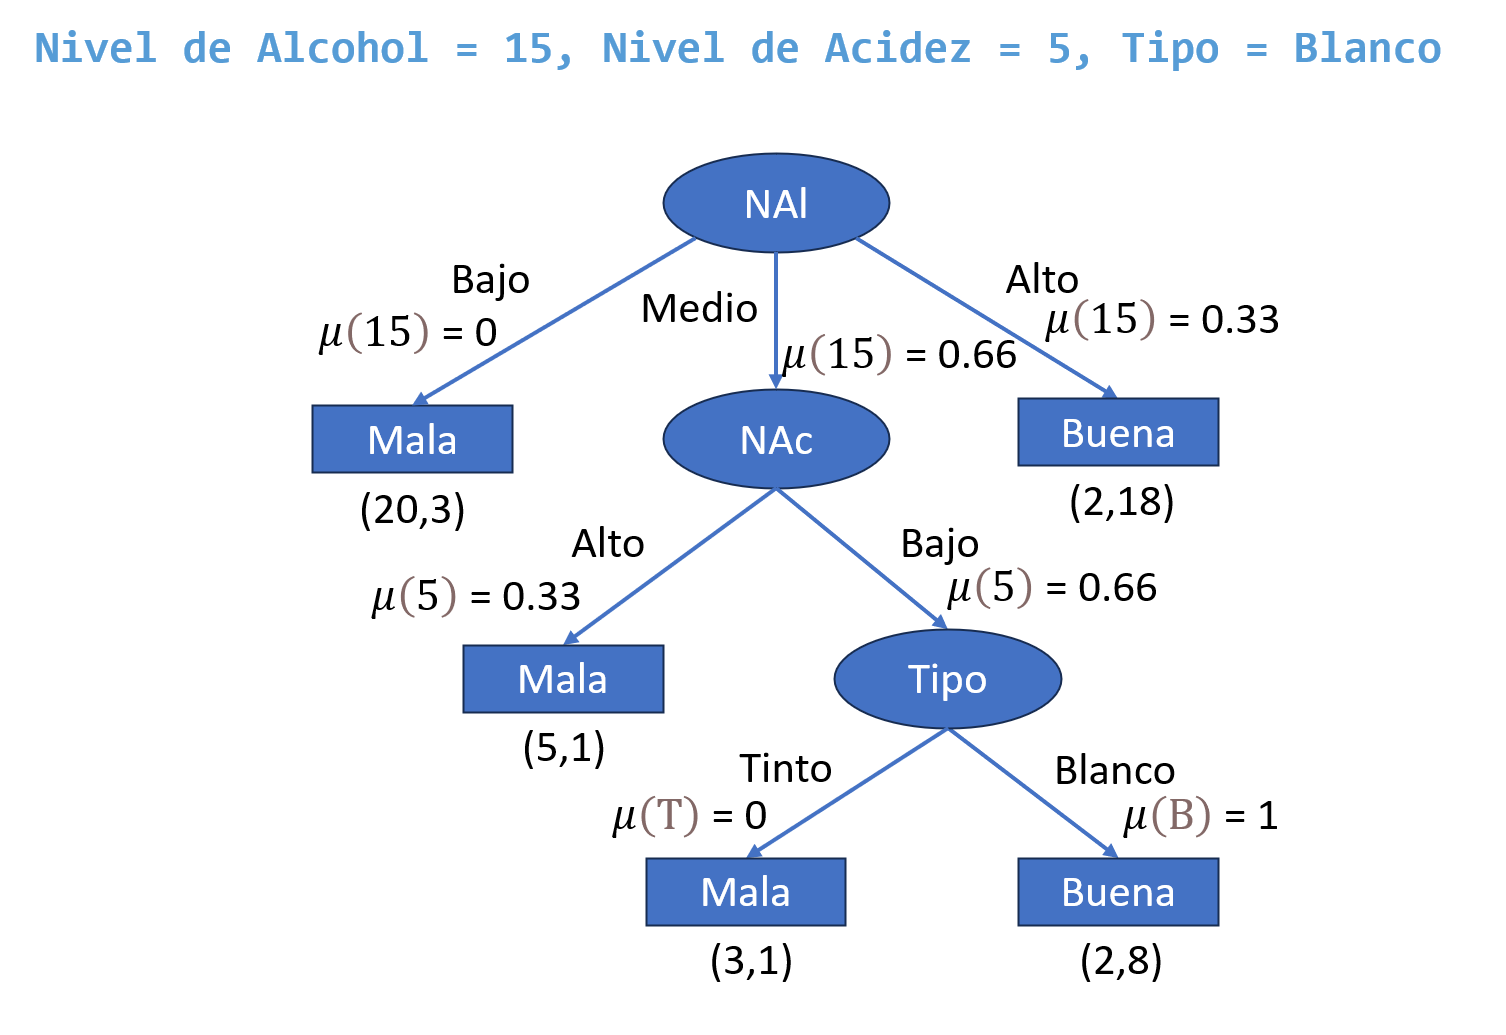


Una vez que tenemos el árbol se pueden procesar los ejemplos para clasificación de forma equivalente a cómo se hacía en los árboles de decisión discretos, pero esta vez ponderando por las funciones de pertenencia y finalmente ponderando por los ejemplos que caen en las diferentes etiquetas cuando se llegue a un nodo hoja. Esto es, se tienen que procesar todas las ramas del árbol. Para cada camino desde la raíz hasta un nodo hoja, debemos de quedarnos con el mínimo de las funciones de pertenencia de los diferentes nodos, este mínimo será el que pondere la importancia del cada etiqueta del nodo hoja junto con la distribución de la clase en dicho nodo hoja.


### <font color="#004D7F"> 1.3 Objetivos de la práctica</font>



El objetivo de esta práctica es el de obtener un sistema basado en reglas difusas para la predicción del salario de la base de datos de ejemplo árboles de decisión y realizar un proceso de inferencia a partir de dicho sistema. Para ello, vamos a llevar a cabo 4 fases:

1. Realizar una transformación de las variables continuas a variables difusas.
2. Obtener un sistema de reglas basado en un árbol de decisión. Esto dará lugar a un árbol de decsición que podríamos considerar como difuso y, por tanto, también podemos utilizar para clasificación difusa.
4. Realizar un clasificador basado en reglas difusas descriptivas lingüísticas y medir el rendimiento del mismo.

Para ello, necesitamos incorporar el algoritmo de aprendizaje de árboles de decisión con variables discretas que implementamos en la práctica número uno. Vamos a utilizar la misma base de datos [`adult`](https://archive.ics.uci.edu/dataset/2/adult), también conocida como [`census-income`](https://archive.ics.uci.edu/dataset/20/census+income). 


---

# 2. Carga del dataset

Estas sección es la misma que en la práctica número uno.
El dataset que usaremos trata de predecir si los ingresos son superiores o inferiores a 50K en base a una serie de variables. Para cargar los datos usaremos `pandas`, mientras que `numpy` será necesario para realizar diversas funciones a lo largo de la práctica.

In [1]:
import numpy as np
import pandas as pd



In [2]:
df = pd.read_csv('adult.csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## 2.1. Análisis exploratorio

Podemos ver información de las distintas variables con `df.info()`:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Así, vemos como efectivamente tenemos tanto variables categóricas como numéricas. En principio parece estar todo correcto, sin valores perdidos, pero si observamos los valores únicos de cada variable:

In [4]:
df.apply(lambda col: col.sort_values().unique())

age               [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...
workclass         [?, Federal-gov, Local-gov, Never-worked, Priv...
fnlwgt            [12285, 13769, 14878, 18827, 19214, 19302, 193...
education         [10th, 11th, 12th, 1st-4th, 5th-6th, 7th-8th, ...
education-num     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
marital-status    [Divorced, Married-AF-spouse, Married-civ-spou...
occupation        [?, Adm-clerical, Armed-Forces, Craft-repair, ...
relationship      [Husband, Not-in-family, Other-relative, Own-c...
race              [Amer-Indian-Eskimo, Asian-Pac-Islander, Black...
sex                                                  [Female, Male]
capital-gain      [0, 114, 401, 594, 914, 991, 1055, 1086, 1111,...
capital-loss      [0, 155, 213, 323, 419, 625, 653, 810, 880, 97...
hours-per-week    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
native-country    [?, Cambodia, Canada, China, Columbia, Cuba, D...
income                                          

Podemos ver cómo en `workclass`, `occupation` y `native-country` hay valores desconocidos representados por `?`. Vamos a ver cómo quedaría nuestro DataFrame si los reemplazamos por `NaN` para que `pandas` los reconozca como valores perdidos:

In [5]:
df.replace('?', np.nan).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Así, ahora podemos ver cómo la cuenta de valores no nulos ha cambiado. Por defecto, como las variables eran categóricas, estaba contando las `?` como una categoría más. 

Cuando conocemos la causa de los valores perdidos puede tener sentido dejarlos como una categoría más. Por ejemplo, suponed que estamos recogiendo datos de un radar en el que la velocidad máxima que puede medir son 200 km/h. Si un coche pasa a 215 km/h el radar nos daría un `?` en ese dato, pero si sabemos el motivo de estos valores perdidos, podríamos cambiar el nombre de esa categoría a `>200km/h`.

Ya que en esta práctica no vamos a introducir el manejo de los valores perdidos en nuestros árboles de decisión, y puesto que dichos valores solo aparecen en variables categóricas, por simplicidad vamos a dejar la base de datos tal cual está, contando a `?` como un valor categórico más. 

## 2.2. De `pandas` a `numpy`

A continuación vamos a transformar nuestros datos en arrays de `numpy` ya que los necesitaremos para trabajar con ellos posteriormente. `pandas` tiene muchas características muy útiles para hacer el análisis exploratorio y el preprocesamiento de los datos gracias a sus funciones de selección, agregación, agrupación... pero posteriormente todos los algoritmos de aprendizaje automático suelen trabajar con arrays de `numpy` dada su velocidad.

Vamos a empezar con los nombres de las variables. Por un lado vamos a guardar cuáles son nuestras variables predictoras y cuál nuestra variable objetivo.

In [6]:
features = df.columns
features

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [7]:
attributes = features[:-1]
target = features[-1]

print('Predictoras:',attributes)
print('Objetivo:',target)

Predictoras: Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')
Objetivo: income


Además, vamos a distinguir entre variables continuas (las que son de tipo `int64`) y discretas (de tipo `object`), ya que a la hora de hacer nuestros árboles de decisión habrá que tratarlas de forma distinta.

In [8]:
cont_atts = df.columns[df.dtypes == 'int64']

disc_atts = df.columns[df.dtypes == 'object'] 
disc_atts = disc_atts.drop(target)

print('Continuas:',cont_atts)
print('Discretas:',disc_atts)

Continuas: Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Discretas: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


Finalmente, separamos el dataset en predictor y objetivo. Es convención en ciencia de datos usar $X$ para las variables predictoras e $y$ para la variable objetivo. La mayoría de los modelos se entrenan usando esas dos variables por separado.

In [9]:
X, y = df[attributes].to_numpy(), df[target].to_numpy()
X

array([[39, 'State-gov', 77516, ..., 0, 40, 'United-States'],
       [50, 'Self-emp-not-inc', 83311, ..., 0, 13, 'United-States'],
       [38, 'Private', 215646, ..., 0, 40, 'United-States'],
       ...,
       [58, 'Private', 151910, ..., 0, 40, 'United-States'],
       [22, 'Private', 201490, ..., 0, 20, 'United-States'],
       [52, 'Self-emp-inc', 287927, ..., 0, 40, 'United-States']],
      dtype=object)

In [10]:
y

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '>50K'],
      dtype=object)

## 2.3. Datos de test

Cuando nos enfrentamos a un problema de aprendizaje automático, es imprescindible que los datos de test que usemos para medir el rendimiento del modelo sean distintos a los datos con los que se entrena. En este caso, como los autores del conjunto de datos nos proporcionan un conjunto de datos separado para test, lo usaremos directamente. Si no, tendríamos que dividir el conjunto de datos original en dos partes, una para entrenar y otra para test.

**Nota:** En la práctica, es común dividir el conjunto de datos en tres partes: entrenamiento, validación y test. La validación se usa para ajustar los hiperparámetros del modelo, y el conjunto de test se usa para medir el rendimiento final del modelo. En este caso, como no vamos a ajustar hiperparámetros y por simplicidad, no usaremos conjunto de validación.

In [11]:
df_test = pd.read_csv('adult_test.csv')
df_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
16277,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [12]:
X_test, y_test = df_test[attributes].to_numpy(), df_test[target].to_numpy()
X_test

array([[25, 'Private', 226802, ..., 0, 40, 'United-States'],
       [38, 'Private', 89814, ..., 0, 50, 'United-States'],
       [28, 'Local-gov', 336951, ..., 0, 40, 'United-States'],
       ...,
       [38, 'Private', 374983, ..., 0, 50, 'United-States'],
       [44, 'Private', 83891, ..., 0, 40, 'United-States'],
       [35, 'Self-emp-inc', 182148, ..., 0, 60, 'United-States']],
      dtype=object)

In [13]:
y_test

array(['<=50K', '<=50K', '>50K', ..., '<=50K', '<=50K', '>50K'],
      dtype=object)

---

# 3. Base de Conocimiento. Definición de las Variables Lingüísticas.



### <font color="#004D7F"> 3.1 Variables Difusas y Conjuntos Difusos</font>

El primer paso será generar las variables difusas a partir de las variables de la base de datos. Para ello, se proporciona el esqueleto de varias clases que os ayudarán a estructurar las variables con los elementos necesarios para la transformación posterior de la base de datos. Para simplificar, se utilizarán conjuntos difusos triangulares para las variables continuas. Utilizaremos el paquete sckit-fuzzy para definir los conjuntos difusos repartidos de forma uniforme como antecedentes y consecuentes. Para ello vamos a definir dos clases para variables difusas numéricas y otra para discretas. La definición de las variables discretas será un poco particular y es recomendable leer bien su código y entender su codificación como otra variable difusa.

##### `NumericFuzzyVariable`

Esta clase representa las variables difusas contínuas. Para ello usamos el metodo automf de sckit-fuzzy. 

Los atributos de la clase serán los siguientes:
  - `name`: Nombre de la variable difusa.
  - `universe`: Que es el universo del discurso, definido a través de un valor máximo y mínimo.
  - `labels`: Que es una lista de etiquetas que queremos para la variable.
  - `fuzzySets`: Los conjuntos difusos definidos para las etiquetas difusas lingüísticas definidas.

Y tendrá las siguientes funciones:
  - `membership`: Función que devuelve el grado de pertenencia de un número real en todos los difusos definidos en las etiquetas.
  - `membership_label`: Función que devuelve el grado de pertenencia de un número real a una etiqueta dada.
  - `fuzzify`: Función que obtiene la etiqueta de la mejor pertenencia a las etiquetas de un valor determinado.





In [14]:
#!pip install scikit-fuzzy
import skfuzzy.control as ctrl
import skfuzzy as fuzz
from operator import and_
from functools import reduce
from itertools import groupby
import random
import matplotlib.pyplot as plt

In [15]:
class NumericFuzzyVariable:
    def __init__(self, name, labels, min, max,output=False):

        self.name = name 
        self.universe = np.linspace(min, max, 100)
        self.labels = labels
        self.max = max
        self.min = min
        
        if output:
            self.fuzzySets = ctrl.Consequent(self.universe, self.name)
        else:
            self.fuzzySets = ctrl.Antecedent(self.universe, self.name)

        self.fuzzySets.automf(names=self.labels)

    def plot_var(self):
         self.fuzzySets.view()
    
    def __repr__(self):
        return f'Fuzzy set "{self.name}" with labels {self.labels}'
    
    def membership(self, x):
        result = []
        for term_idx in self.fuzzySets.terms:
            mf_t = self.fuzzySets[term_idx].mf
            #print(mf_t)
            grado_pertenencia = fuzz.interp_membership(self.universe,mf_t,x)
            #print(grado_pertenencia)
            result.append(grado_pertenencia)
        return result
    
    #Función para obtener el grado de pertenencia de un valor a un conjunto difuso dada la etiqueta.

    def membership_label(self, x, label):
        mf_t = self.fuzzySets[label].mf
        #print(mf_t)
        grado_pertenencia = fuzz.interp_membership(self.universe,mf_t,x)
        #print(grado_pertenencia)
        return grado_pertenencia

    #Función para obtener el conjunto difuso/etiqueta que mejor defina un valor (máxima pertenencia a una etiqueta)
    #Si mf_values es True, devuelve el nombre de la etiqueta y el grado de pertenencia. Si no, solo el nombre de la etiqueta.
      
    def fuzzify(self, value, mf_values = False):
        #TO DO
        pass


c:\Users\Jose.Puerta\AppData\Local\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[0.0, 0.8800000000000001, 0.11999999999999994]
medio
0.8800000000000001
Fuzzy set "VariableContinua" with labels ['bajo', 'medio', 'alto']


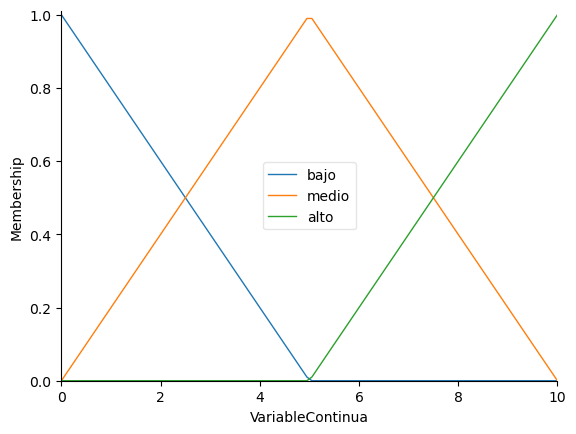

In [16]:
FV = NumericFuzzyVariable("VariableContinua",['bajo','medio','alto'],0,10)
FV.plot_var()
print(FV.membership(5.6))
print(FV.fuzzify(5.6))
print(FV.membership_label(5.6,'medio'))
print(FV)

##### `DiscreteFuzzyVariable`

Esta clase representa las variables difusas discretas. Para ello usamos una codificación puntal para cada índice de los valores de la variable. 

Los atributos de la clase serán los siguientes:
  - `name`: Nombre de la variable difusa.
  - `universe`: Que es el universo del discurso, definido a través del número de valores de la varaible. Se codifica desde 0 al número máximo de valores -1, en el orden que se les pase estos valores.
  - `labels`: Que es una lista de etiquetas de los valores de la variable discreta.
  - `fuzzySets`: Que definen valores puntuales para cada valor de la etiqueta, esto es, pertenencia de 0 o 1 para cada uno de los valores del universo del discurso.

Y tendrá las siguientes funciones:
  - `membership`: Función que devuelve el grado de pertenencia de un número real en todos los difusos definidos en las etiquetas.
  - `label`: Función que devuelve la etiqueta del valor de unos de los valores codificados en el universo del discurso.
  - `id_label`: Función que devuelve la codificación en el universo del discurso de la etiqueta que se le pase o valor discreto de la variable.

In [17]:
class DiscreteFuzzyVariable:
    def __init__(self, name, labels, output=False):

        self.name = name
        self.universe = np.linspace(0, len(labels)-1, len(labels)).astype('int')
        self.labels = labels

        if output:
            self.fuzzySets = ctrl.Consequent(self.universe, self.name)
        else:
            self.fuzzySets = ctrl.Antecedent(self.universe, self.name)
            
        self.fuzzySets.automf(names=self.labels)

    def plot_var(self):

        fig, ax = plt.subplots()
        x = self.universe
        labels = self.labels
        num_labels = len(self.labels)
        bar_width = 1 / (num_labels + 1)
        for i, label in enumerate(labels):
            membership = [self.membership(value)[i] for value in x]
            ax.bar(x , membership, width=bar_width, label=label)
        ax.set_xlabel('Universo del Discurso')
        ax.set_ylabel('Grado de Pertenencia')
        ax.set_title(f'Variable Difusa: {self.name}')
        ax.set_xticks(x)
        ax.legend()
        plt.show()
    
    def __repr__(self):
        return f'Fuzzy set "{self.name}" with labels {self.labels}'
    
    def membership(self, x):
        result = []
        for term_idx in self.fuzzySets.terms:
            mf_t = self.fuzzySets[term_idx].mf
            grado_pertenencia = fuzz.interp_membership(self.universe,mf_t,x)
            result.append(int(grado_pertenencia))
        return result
    
    def label(self, x):
        best_label = None
        best_membership = 0
        result = self.membership(x)
        array_np = np.array(result)
        best_label = np.argmax(array_np)
        return self.labels[best_label]
    
    def id_label(self, label):
        return self.labels.index(label)


Fuzzy set "VariableDiscreta" with labels ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
[0, 0, 1, 0, 0, 0, 0]
2
Miercoles


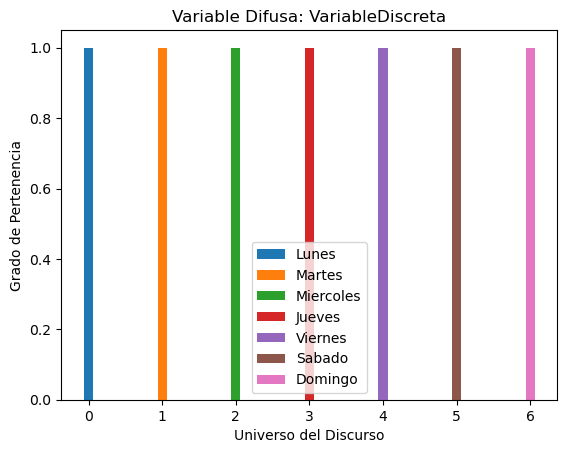

In [18]:
DFV = DiscreteFuzzyVariable('VariableDiscreta',['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo'])
print(DFV)
print(DFV.membership(2))
print(DFV.id_label('Miercoles'))
print(DFV.label(2))
DFV.plot_var()

## 3.1. Transformación de los datos FUZZIFICACION

Vamos a transformar nuestros datos todos ellos en etiquetas. Las variables discretas seguirán siendo igual, pero hay que crear las variables difusas correspondientes. Las variables contínuas hay que definir sus variables difusas correspondientes.

Una vez creada la base de etiquetas difusas linguisticas, debemos procesar la base de datos para fuzzificar las varibles continuas sustituyendo sus valores continuos por la etiqueta difusa con una mayor grado de pertenecia. En esta práctica asumiremos que todas las variables contínuas tienen las mismas etiquetas difusas lingüísticas. En concreto vamos a establecer para todas ellas 3 etiquetas difusas: ['Low', 'Mid', 'High'] por defecto. Estas etiquetas tendrán una distribución de conjuntos difusos simétricos y uniformemente distribuidos.

In [19]:
features = df.columns
attributes = features[:-1]
print(attributes)
cont_atts = df.columns[df.dtypes == 'int64']
disc_atts = df.columns[df.dtypes == 'object'] 
disc_atts = disc_atts.drop(target)

print('Continuas:',cont_atts)
print('Discretas:',disc_atts)

cont_atts_indices = features.get_indexer(cont_atts)
disc_atts_indices = features.get_indexer(disc_atts)

print("Índices de las variables continuas:", cont_atts_indices)
print("Índices de las variables discretas:", disc_atts_indices)


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')
Continuas: Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Discretas: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')
Índices de las variables continuas: [ 0  2  4 10 11 12]
Índices de las variables discretas: [ 1  3  5  6  7  8  9 13]


In [20]:
class FuzzyEncoder():

    # constructor
    # attributes: lista de nombres de las columnas
    # cont_atts: lista de nombres de las columnas continuas
    # disc_atts: lista de nombres de las columnas discretas
    # labels: lista de etiquetas difusas

    def __init__(self, attributes, cont_atts, disc_atts,labels=['Low', 'Mid', 'High']):
        self.fuzzy_variables = {}
        self.labels = labels
        self.sets = len(labels)
        self.attributes = attributes
        self.cont_atts = cont_atts
        self.disc_atts = disc_atts

    # Creamos las funciones fit para la transformación de los datos preparando los conjuntos difusos de las etiquetas difusas linguisticas
    def fit(self, X):
        #TO DO
        # Obtener los índices de las variables continuas y discretas
        # Crear un diccionario con las variables difusas continuas y discretas
        # Crear un conjunto difuso para cada variable difusa
        # Añadir las variables difusas al diccionario
        pass

    # Creamos la función transform para la transformación de los datos una vez definidos los conjuntos difusos de la etiquetas difusas linguisticas
    def transform(self, X):
         # Asumiendo que `attributes` contiene los nombres de las columnas en el orden correcto
        new_X = np.copy(X)  # Hacer una copia de X para no modificar el original
        #TO DO
        # Iterar sobre las columnas de X
        # Para cada columna, obtener el nombre del atributo y el conjunto difuso correspondiente
        # Aplicar la función fuzzify de la variable difusa correspondiente a cada elemento de la columna
        pass

    # Creamos la función fit_transform para la transformación de los datos una vez definidos los conjuntos difusos de la etiquetas difusas linguisticas
    def fit_transform(self, X):
        return self.fit(X).transform(X)
    

In [21]:
fuzzy_encoder = FuzzyEncoder(attributes, cont_atts, disc_atts)
fuzzy_encoder.fit(np.concatenate([X,X_test], axis=0))
fuzzy_X = fuzzy_encoder.transform(X)

Como en el test nos falta una columna (ya que alguna categoría en alguna variable no aparecerá), tenemos que añadirla para no tener problemas posteriores.

In [22]:
print(fuzzy_X)

[['Mid' 'State-gov' 'Low' ... 'Low' 'Mid' 'United-States']
 ['Mid' 'Self-emp-not-inc' 'Low' ... 'Low' 'Low' 'United-States']
 ['Mid' 'Private' 'Low' ... 'Low' 'Mid' 'United-States']
 ...
 ['Mid' 'Private' 'Low' ... 'Low' 'Mid' 'United-States']
 ['Low' 'Private' 'Low' ... 'Low' 'Low' 'United-States']
 ['Mid' 'Self-emp-inc' 'Low' ... 'Low' 'Mid' 'United-States']]


Una vez definido el transformador FuzzyEncoder también tenemos que fuzzyficar la variable objetivo. Para ello vamos a definir una variable contínua con el universo del discurso de 0 a 1, de tal forma que definamos también tantas etiquetas como clases haya en el problema distribuidas de forma uniforme y triangulares. Para ello utilizamos la clase que hemos definido anteriormente.


['<=50K', '>50K']
income


c:\Users\Jose.Puerta\AppData\Local\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


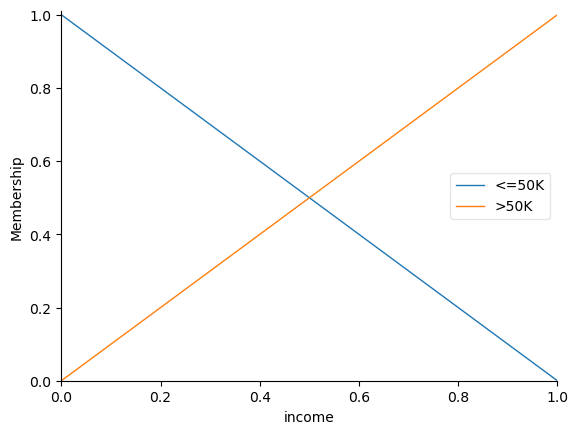

In [23]:
column_data = y
unique_labels = np.unique(column_data)  # Usar np.unique para obtener valores únicos
fuzzy_y = NumericFuzzyVariable(target,[label for label in unique_labels], 0.0, 1.0, output=True)
print(fuzzy_y.labels)   
print(target)
fuzzy_y.plot_var()

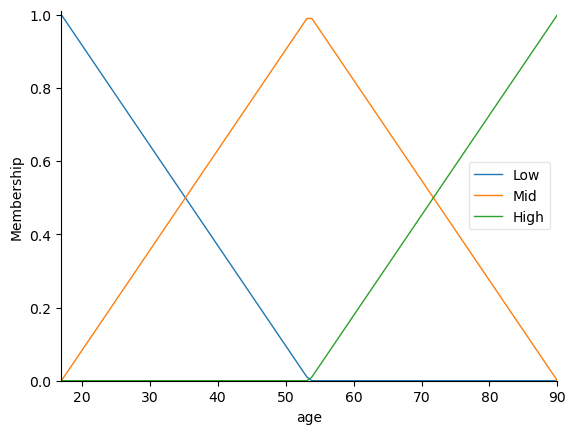

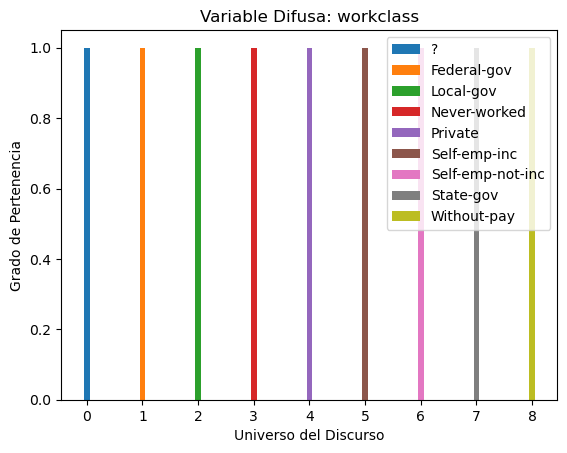

{'age': Fuzzy set "age" with labels ['Low', 'Mid', 'High'],
 'fnlwgt': Fuzzy set "fnlwgt" with labels ['Low', 'Mid', 'High'],
 'education-num': Fuzzy set "education-num" with labels ['Low', 'Mid', 'High'],
 'capital-gain': Fuzzy set "capital-gain" with labels ['Low', 'Mid', 'High'],
 'capital-loss': Fuzzy set "capital-loss" with labels ['Low', 'Mid', 'High'],
 'hours-per-week': Fuzzy set "hours-per-week" with labels ['Low', 'Mid', 'High'],
 'workclass': Fuzzy set "workclass" with labels ['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'],
 'education': Fuzzy set "education" with labels ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college'],
 'marital-status': Fuzzy set "marital-status" with labels ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-mar

In [24]:
fuzzy_encoder.fuzzy_variables['age'].plot_var()
fuzzy_encoder.fuzzy_variables['workclass'].plot_var()
fuzzy_encoder.fuzzy_variables

--- 

# 4.  árbol de clasificación Difuso

En este apartado vamos a utilizar la implementación del árbol de decisión de la práctica anterior para variables discretas para aprender uno a partir de la base de datos fuzzificada.


- `__init__()`: Constructor del modelo, recibirá los hiperparámetros necesarios.
- `fit(X,y)`: Método de entrenamiento del modelo. Recibe $X$ e $y$ y devuelve el modelo ya entrenado.
- `predict(X)`: Método de predicción del modelo. Recibe $X$ como un conjunto de instancias a predecir y devuelve $y_{pred}$, un vector de predicciones asociadas a $X$.


## 4.1 Clase `Node`
Antes de implementar la clase principal `C45Classifier`, vamos a crear una clase `Node` que codifique la información necesaria para cada uno de los nodos del árbol. Cuenta con las siguientes funciones:
- `__init__(self):` Constructor. En él inicializamos las variables necesarias, explicadas en los comentarios del código.
- `__str__(self):` Método que nos permite imprimir nuestros árboles.
- `predict(self,x):` Método que nos permitirá hacer predicciones recursivamente hasta llegar a un nodo hoja. Cuando el `Node` es hoja devuelve el valor de su clase, y si no, tendrá que llamar a la función `predict(x)` del hijo que corresponda. 

A esta clase a se le ha añadido con respecto a la práctica anterior una nueva variable miembro para almacenar la distribución entre las clases que hay en un nodo hoja. Con esta variable podríamos saber y almacenar la probabilidad de las clases en dicho nodo hoja.

In [25]:

class Node:
    def __init__(self):
        # Indica si el nodo es una hoja, o no
        self.is_leaf = False

        # Atributos relacionados con la variable que representa el nodo
       
        self.cat_dict = None    # Diccionario para variables categóricas con formato {valor: indice}
        
        # Atributos cuando el objeto es una raíz
        self.var = None         # Nombre de la variable de corte
        self.var_index = -1     # Índice de la variable de corte
        self.cut_value = 0      # Valor de la variable de corte, en caso de ser numérica
        self.children = []      # Lista de hijos

        # Atributos cuando el objeto es una hoja
        self.class_value = -1       # Valor de la clase si el nodo es hoja
        self.class_count = (0,0)    # Tupla con el formato (casos con valor class_value, casos totales en la hoja)
        # Profundidad del nodo
        self.depth = -1

        # ESTO ES NUEVO
        self.class_distribution = 0 # Distribución de clases en la hoja

    def __str__(self):
        output = ''
        if(self.is_leaf):
            output += 'Class value: ' + str(self.class_value) + '\tCounts: ' + str(self.class_count) + '\tCounts: ' + str(self.class_distribution)
        else:
            output += 'Feature '+ str(self.var)
            for i in range(len(self.children)):
                output += '\n'+'\t'*(self.depth+1)+str(self.cut_value)+': '+str(self.children[i]) 
            
        return output
    
    # Esta función nos servirá para hacer predicciones recursivamente hasta llegar a un nodo hoja. Debe ser completada
    def predict(self,x):
        if self.is_leaf:
            return self.class_value
        else:
            if x[self.var_index] in self.cat_dict:
                child_index = self.cat_dict[x[self.var_index]]
                return self.children[child_index].predict(x)
            else: # Cuando nos llega un x nunca visto, elegimos una rama aleatoriamente.
                return random.choice(self.children).predict(x)

## 4.2 Clase `C45Classifier`
Esta será la clase principal, que representará nuestro clasificador C4.5. Los argumentos que recibirá serán los siguientes:
* `vars`, `disc`, `cont`: 3 listas. Nombres de las variables con el mismo orden con el que aparecen en $X$, y de ellas, cuáles son discretas y cuales son continuas. No sería estrictamente necesario, pero simplificará bastante el desarrollo de la práctica.
* `max_depth`: Profundidad máxima del árbol. Si no se especifica, será 2.
* `criterion`: Criterio de partición. Puede tomar los valores `classification_error`, `entropy` y `gini`. Si no se especifica, será 'entropy'.
* `prune`: Booleano. Si es `True`, se podará el árbol. Si no se especifica, será `False`.

Es la parte discreta del aprendizaje del árbol de decisión, para esta práctica no necesitamos la parte de las variables contínuas. Tampoco está implementada la parte de poda ni todos los criterios de decisión de ramificación. Podeis trasladar vuestras implementaciones a esta práctica.

In [26]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from scipy.stats import entropy

# Función para calcular la entropía
from scipy.stats import entropy # pip install scipy

class C45Classifier(BaseEstimator, ClassifierMixin):

    # Constructor de la clase, aquí se definen e inicializan las variables de la clase.
    def __init__(self, vars, max_depth=2, criterion='classification_error', prune=False):

        self.max_depth = max_depth
        self.criterion = criterion
        self.prune = prune
        self.vars = vars
        self.class_dict = None
     
        # Diccionario que nos permitirá convertir el nombre de la variable en su índice.
        self.features_dict = {feat: i for i, feat in enumerate(self.vars)}

        # Raíz del árbol
        self.tree = Node()   


    # Función para entrenar el modelo.
    def fit(self, X, y):
        self.class_dict = {clase: i for i, clase in enumerate(np.unique(y))}
        # Llamada a la función recursiva que aprende el árbol.
        self._partial_fit(X, y, self.tree, 0, set([]))

        if self.prune:
            self._prune_tree()
        
        return self
    

    # Función para hacer predicciones.
    def predict(self, X):
        return np.array([self.tree.predict(x) for x in X])
    

    # Función recursiva que busca la variable y corte que maximiza la ganancia de información.
    # - Las variables continuas se tratan con un corte binario, lo que quiere decir que pueden ser usadas multiples veces. 
    # - Las variables discretas ramifican tantas veces como valores tengan, asi que solo pueden ser usadas una vez por camino, 
    #   debiendo almacenarlas en el conjunto `borradas`.

    def _partial_fit(self, X, y, current_tree, current_depth, borradas):
        # Función auxiliar para convertir el nodo actual en hoja.
        def _make_leaf():
            current_tree.is_leaf = True
            valores, counts = np.unique(y, return_counts=True)
            max_count_position = np.argmax(counts)
            current_tree.class_value = valores[max_count_position]
            current_tree.class_count = [counts[max_count_position], len(y)]
            # ESTO ES NUEVO
            current_tree.class_distribution = {} # Diccionario con la distribución de clases en la hoja.
            # Calculamos la distribución de clases en la hoja.
            for valor in self.class_dict.keys():
                current_tree.class_distribution[valor] = 0

            for i,valor in enumerate(valores):
                current_tree.class_distribution[valor] = counts[i]/len(y)
            return
        
        # Antes de nada, si hemos alcanzado la profundidad máxima, el nodo se convierte en hoja.
        if current_depth >= self.max_depth:
            _make_leaf()
            return

        # Primero obtenemos el mejor punto de corte para el nodo actual dependiendo del criterio.
        if self.criterion == 'entropy':
            best_var = self._split_entropy(X, y, borradas)
        elif self.criterion == 'classification_error':
            best_var = self._split_classification_error(X, y, borradas)

        # Si no hay ninguna partición que mejore la actual, el nodo se convierte en hoja.
        if best_var is None:
            _make_leaf()
            return
    
        # Antes de llamar a la función recursiva, hay que actualizar los valores del árbol.
        borradas_copy = borradas.copy()
        current_tree.is_leaf = False
        current_tree.depth = current_depth
        current_tree.var = best_var
        current_tree.var_index = self.features_dict[best_var]

        # Finalmente, se hace la llamada recursiva en función de si es numérica o categórica.
    
        index = self.features_dict[best_var]
        current_tree.cat_dict = {feat: i for i, feat in enumerate(np.unique(X[:,index]))}
        for value in np.unique(X[:,index]):
                child = Node()
                ind = X[:,index] == value
                current_tree.children.append(child)
                self._partial_fit(X[ind], y[ind], child, current_depth + 1, borradas_copy)
        
        return


    # Cálculo del mejor punto de corte en función de: Error de clasificación.
    def _split_classification_error(self, X, y, borradas):
        # Error actual (sin partición)
        error_initial = self._classification_error(y)
        best_var = None
        error_best = 1
        for var in self.vars:
            index = self.features_dict[var]
            # Error particionando por X[index]
            # Para cada valor de la variable:
            for value in np.unique(X[:,index]):
                 # Obtener solo los valores de y en los que X[:,index] == value
                ind = X[:,index] == value
                y_values = y[ind]
                # Calcular el error que se obtendría
                error = self._classification_error(y_values)
                if error < error_best:
                    error_best = error
                    best_var = var
   
            # Si conseguimos un error de 0 (óptimo), terminamos
            if error_best == 0:
                break

        return best_var
    
    def _classification_error(self, y):
        valores, counts = np.unique(y, return_counts=True)
        max_count = np.max(counts)
        return 1 - max_count / len(y)

   
    def _split_entropy(self, X, y, borradas):
        # Entropía actual (sin partición)
        entropy_initial = entropy(np.unique(y, return_counts=True)[1], base=2)
        best_var = None
        info_gain_best = 0
        for var in self.vars:
            index = self.features_dict[var]
            if var in borradas:
                continue
            # entropía particionando por X[index]
            # Para cada valor de la variable:
            cond_entropy = 0
            for value in np.unique(X[:,index]):
                # Obtener solo los valores de y en los que X[:,index] == value
                ind = X[:,index] == value
                y_values = y[ind]
                if var in borradas:
                    continue
                unique_values, value_counts = np.unique(y_values, return_counts=True)
                entropy_value = entropy(value_counts, base=2)
                cond_entropy += len(y_values)/len(y)*entropy_value   

            info_gain = entropy_initial-cond_entropy 
            if info_gain > info_gain_best:
                info_gain_best = info_gain
                best_var = var
           
        return best_var
    
    # TODO: Completar esta función para realizar la poda del modelo.
    def _prune_tree(self):
        pass

    # Función para imprimir el modelo.
    def __str__(self):
        return str(self.tree)
    

In [27]:
arbol = C45Classifier(attributes, max_depth=2, criterion='entropy', prune=False)
_ = arbol.fit(fuzzy_X,y)

In [28]:
print(arbol)

Feature relationship
	0: Feature education
		0: Class value: <=50K	Counts: [261, 313]	Counts: {'<=50K': 0.8338658146964856, '>50K': 0.16613418530351437}
		0: Class value: <=50K	Counts: [271, 311]	Counts: {'<=50K': 0.8713826366559485, '>50K': 0.12861736334405144}
		0: Class value: <=50K	Counts: [78, 103]	Counts: {'<=50K': 0.7572815533980582, '>50K': 0.24271844660194175}
		0: Class value: <=50K	Counts: [64, 70]	Counts: {'<=50K': 0.9142857142857143, '>50K': 0.08571428571428572}
		0: Class value: <=50K	Counts: [136, 149]	Counts: {'<=50K': 0.912751677852349, '>50K': 0.087248322147651}
		0: Class value: <=50K	Counts: [299, 333]	Counts: {'<=50K': 0.8978978978978979, '>50K': 0.1021021021021021}
		0: Class value: <=50K	Counts: [186, 202]	Counts: {'<=50K': 0.9207920792079208, '>50K': 0.07920792079207921}
		0: Class value: <=50K	Counts: [195, 380]	Counts: {'<=50K': 0.5131578947368421, '>50K': 0.4868421052631579}
		0: Class value: <=50K	Counts: [331, 596]	Counts: {'<=50K': 0.5553691275167785, '>50

In [29]:
arbol.predict(fuzzy_X)

array(['<=50K', '>50K', '<=50K', ..., '<=50K', '<=50K', '>50K'],
      dtype='<U5')

In [30]:
print("Error en train: ", arbol.score(fuzzy_X,y))
print("Error en test: ",arbol.score(fuzzy_encoder.transform(X_test),y_test))

Error en train:  0.8213506956174564
Error en test:  0.8209569436766784


--- 

# 5.  Construcción del Sistema basado en Reglas Difusas Descriptivas tipo Mandani a partir del árbol de clasificación Difuso

En este apartado vamos a utilizar el modelo de árbol que hemos aprendido con la base de datos fuzzificada. Tenemos dos formas de hacer un clasificador difuso. El primero de ellos es traduciendo las reglas del árbol generado a reglas difusas y utilizar éstas posteriormente con la inferencia tipo Mandani para clasificar los ejemplos de entrada. El segundo de los métodos va a ser directamente utilizar el propio árbol de decisión en donde hagamos una clasificación difusa. Este proceso será un recorrido recursivo desde la raiz hasta las diferentes hojas y un postprocesado para ver la salida de la etiqueta correspondiente a cada ejemplo de entrada. A diferencia de la práctica anterior en este método no se recorrerá solo una camino sino todos los caminos posibles ya que representan todas las reglas posibles que se pueden disparar.

Para ello vamos a implementar una clase denominada `TreeRuleBasedSystem` donde implemntaremos todos los métodos necesarios para hacer la clasificación de un conjunto de datos.


- `__init__()`: Constructor del modelo, recibirá los hiperparámetros necesarios.
- `fit(X,y)`: Método de entrenamiento del modelo. Recibe $X$ e $y$ y devuelve el modelo ya entrenado.
- `predict(X)`: Método de predicción del modelo. Recibe $X$ como un conjunto de instancias a predecir y devuelve $y_{pred}$, un vector de predicciones asociadas a $X$.

In [31]:

class TreeRuleBasedSystem:
    def __init__(self, fuzzy_variables, target, features_dict):
        """
        Initialize the class with the given parameters.

        Parameters:
        fuzzy_variables (list): A list of fuzzy variables.
        target (str): The target variable.
        features_dict (dict): A dictionary containing the features.

        Returns:
        None
        """ 
        self.fuzzy_variables = fuzzy_variables # List of fuzzy variables
        self.used_fuzzy_vars = [] # List to store the used fuzzy variables
        self.used_idx_fuzzy_vars = [] # List to store the used indexes of the fuzzy variables
        self.features_dict = features_dict # Dictionary containing the features
        self.rules = [] # List to store the rules
        self.target = target # Target Fuzzy variable
        self.system = None #ctrl.ControlSystem(rules=seft.rules)
        self.sim = None #ctrl.ControlSystemSimulation(seft.system)
    
    # Function to create the rule-based system from a list of rules prevoiusly extracted from a tree. The codification of the rules is the following:
    # [((var1, label1), (var2, label2), ...), class], where (var, label) is a tuple representing the variable and the label, and class is the class value.
        
    def _create_rbs(self, rule_list):
        
        for rule in rule_list:
            antecedents = rule[0]
            consequent = rule[1]
            condiciones_antecedente = []
            for ant in antecedents:
                condiciones_antecedente.append(self.fuzzy_variables[ant[0]].fuzzySets.terms[ant[1]])
           # print(condiciones_antecedente)    
            consecuente = self.target.fuzzySets.terms[consequent]
           # print(consecuente)
            antecedente_concat = reduce(and_, condiciones_antecedente)
           # print(antecedente_concat)
            self.rules.append(ctrl.Rule(antecedente_concat, consecuente))
            
    # Function to extract the rules from a tree. The rules are extracted in the following format:
    # [((var1, label1), (var2, label2), ...), class], where (var, label) is a tuple representing the variable and the label, and class is the class value.    
            
    def _extract_rules(self, tree, cr=[]):
        #TO DO
        # Extract the rules from the tree
        # Return a list of rules
        pass
    
    # Function to predict the class of a given instance using the rule-based system. The input is a list of instances, and the output is a list of class values.

    def predict_SBR(self, X):
        predictions = []
        for x in X:
            for i, var in zip(self.used_idx_fuzzy_vars,self.used_fuzzy_vars):
                #print(i, var, x)
                if isinstance(self.fuzzy_variables[var], NumericFuzzyVariable):
                    self.sim.input[var] = x[i]
                else:
                    self.sim.input[var] = self.fuzzy_variables[var].id_label(x[i])
            try:
                self.sim.compute()
                pred = self.sim.output[self.target.name]
            except ValueError as e:
                print("Warning:", e)
                pred = 0
            predictions.append(self.target.fuzzify(pred))

        return predictions 
    
    #
    # Function to predict the class of a given instance using the own decision tree. The input is a list of instances, and the output is a list of class values.
    #
    def predict(self, tree, X):
        predictions = [] # List to store the predictions
        for x in X: # Iterate over the instances
            grouped_predictions = (self._partial_predict(tree, x, 1.0)) # Get the predictions for the instance
            sums = {} # Dictionary to store the sums of the predictions
            for label, group in groupby(sorted(grouped_predictions, key=lambda y: y[0]), key=lambda y: y[0]): # Group the predictions by class
                total_value = sum(y[1] for y in group) # Sum the predictions
                sums[label] = total_value # Store the sum in the dictionary
            p_label = max(sums.items(), key=lambda y: y[1])[0]  # Get the class with the maximum sum
            predictions.append(p_label) # Append the class to the predictions list
        return predictions
    #
    #

    def _partial_predict(self, tree, x, min_mf): 

        if tree.is_leaf: # If the node is a leaf, return the class distribution
            vals = tree.class_distribution.values() 
            classes = tree.class_distribution.keys() 
            return [(cl, val*min_mf) for cl, val in zip(classes, vals)] 
        else:
            #TO DO
            # Predict the class of the instance
            
            val = x[self.features_dict[tree.var]]
            if isinstance(self.fuzzy_variables[tree.var], DiscreteFuzzyVariable):
                # If the variable is discrete, get the membership value of the label
                # If the value is in the category dictionary, get the child index and call the function recursively
                if val in tree.cat_dict:
                   return
                else:
                    # Choose a random child if the value is not in the category dictionary
                    return      
            else:
                # If the variable is continuous, get the membership value of the value
                # Call the function recursively for each child
                values = self.fuzzy_variables[tree.var].membership(val)
                return
                
    def fit(self, tree):
        rule_list = self._extract_rules(tree)
        self._create_rbs(rule_list)
        self.system = ctrl.ControlSystem(rules=self.rules)
        self.sim = ctrl.ControlSystemSimulation(self.system)

    def score(self, X, y, tree = None):
        if tree is None:
            predictions = self.predict_SBR(X)
        else:
            predictions = self.predict(tree, X)
            
        return sum(predictions == y)/len(y)

In [32]:
SBC = TreeRuleBasedSystem(fuzzy_encoder.fuzzy_variables,fuzzy_y, arbol.features_dict)
print(arbol.features_dict)
print(fuzzy_encoder.fuzzy_variables)
print(fuzzy_y)
print(fuzzy_y.fuzzify(0.3))

{'age': 0, 'workclass': 1, 'fnlwgt': 2, 'education': 3, 'education-num': 4, 'marital-status': 5, 'occupation': 6, 'relationship': 7, 'race': 8, 'sex': 9, 'capital-gain': 10, 'capital-loss': 11, 'hours-per-week': 12, 'native-country': 13}
{'age': Fuzzy set "age" with labels ['Low', 'Mid', 'High'], 'fnlwgt': Fuzzy set "fnlwgt" with labels ['Low', 'Mid', 'High'], 'education-num': Fuzzy set "education-num" with labels ['Low', 'Mid', 'High'], 'capital-gain': Fuzzy set "capital-gain" with labels ['Low', 'Mid', 'High'], 'capital-loss': Fuzzy set "capital-loss" with labels ['Low', 'Mid', 'High'], 'hours-per-week': Fuzzy set "hours-per-week" with labels ['Low', 'Mid', 'High'], 'workclass': Fuzzy set "workclass" with labels ['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'], 'education': Fuzzy set "education" with labels ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors'

In [33]:
SBC.fit(arbol.tree)

In [34]:
print(SBC.predict(arbol.tree, X_test[0:10]))
SBC.score( X_test, y_test, arbol.tree)

['<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K']


0.8209569436766784

In [35]:
print(SBC.used_fuzzy_vars)
print(SBC.used_idx_fuzzy_vars)
SBC.rules

['relationship', 'education', 'occupation', 'marital-status']
[7, 3, 6, 5]


[IF relationship[Husband] AND education[10th] THEN income[<=50K]
 	AND aggregation function : fmin
 	OR aggregation function  : fmax,
 IF relationship[Husband] AND education[11th] THEN income[<=50K]
 	AND aggregation function : fmin
 	OR aggregation function  : fmax,
 IF relationship[Husband] AND education[12th] THEN income[<=50K]
 	AND aggregation function : fmin
 	OR aggregation function  : fmax,
 IF relationship[Husband] AND education[1st-4th] THEN income[<=50K]
 	AND aggregation function : fmin
 	OR aggregation function  : fmax,
 IF relationship[Husband] AND education[5th-6th] THEN income[<=50K]
 	AND aggregation function : fmin
 	OR aggregation function  : fmax,
 IF relationship[Husband] AND education[7th-8th] THEN income[<=50K]
 	AND aggregation function : fmin
 	OR aggregation function  : fmax,
 IF relationship[Husband] AND education[9th] THEN income[<=50K]
 	AND aggregation function : fmin
 	OR aggregation function  : fmax,
 IF relationship[Husband] AND education[Assoc-acdm] TH

In [40]:
SBC.score(X_test, y_test)

Error: Crisp output cannot be calculated, likely because the system is too sparse. Check to make sure this set of input values will activate at least one connected Term in each Antecedent via the current set of Rules.
Error: Crisp output cannot be calculated, likely because the system is too sparse. Check to make sure this set of input values will activate at least one connected Term in each Antecedent via the current set of Rules.
Error: Crisp output cannot be calculated, likely because the system is too sparse. Check to make sure this set of input values will activate at least one connected Term in each Antecedent via the current set of Rules.
Error: Crisp output cannot be calculated, likely because the system is too sparse. Check to make sure this set of input values will activate at least one connected Term in each Antecedent via the current set of Rules.
Error: Crisp output cannot be calculated, likely because the system is too sparse. Check to make sure this set of input values w

0.8128493335790185